<a href="https://colab.research.google.com/github/ZahirulNiloyCodes/437Project/blob/main/CSE437Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'craigslist-carstrucks-data' dataset.
PCA Explained Variance: [0.73763501 0.25080123 0.01156376]
      Model  RMSE (log)  MAE (log)        R2    MAPE (%)
0  Baseline    0.892188   0.702503 -0.019460  125.983010
1     Ridge    0.500084   0.303548  0.679710   59.388970
2   XGBoost    0.394912   0.234037  0.800263   36.032864


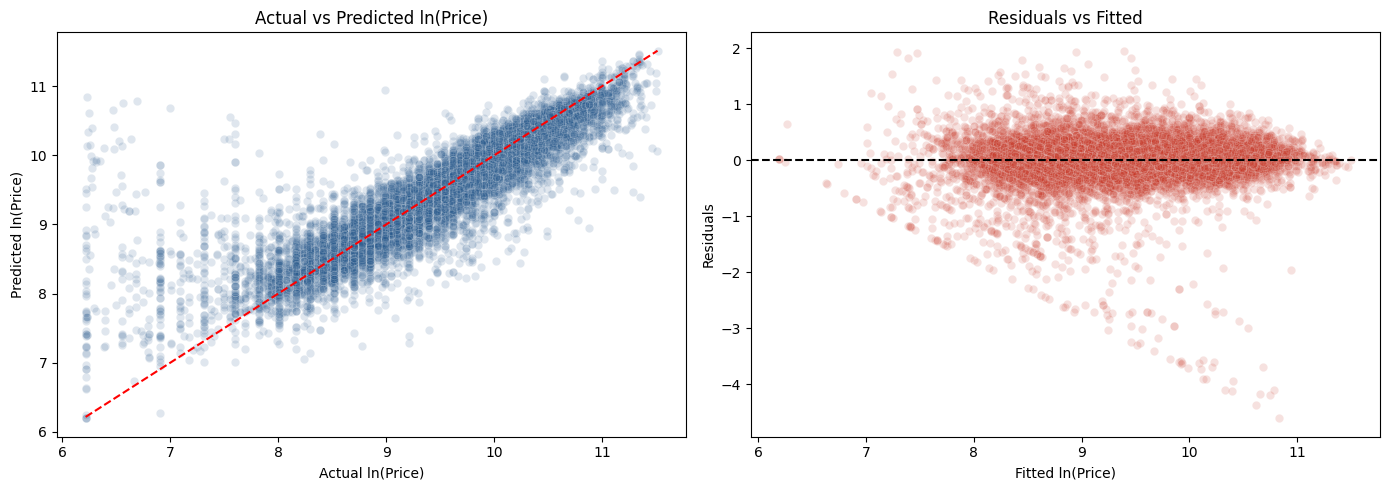

Q1 - Median Price Decay by Type:
type          sedan    truck   pickup
age_bucket                           
(0, 3]          NaN      NaN      NaN
(3, 7]      28590.0  49465.0  36790.0
(7, 12]     16995.0  33997.0  32990.0
(12, 30]     6900.0  15999.0  17200.0

Q2 - Top 5 and Bottom 5 State Residual Deviations:
state
sd   -0.101955
ut   -0.098071
wy   -0.072142
wv    0.084766
hi    0.097018
ne    0.141002
Name: residual_log, dtype: float64

Q3 - Median Price Disparity (Condition vs Title):
By Title Status:
 title_status
clean         16590.0
lien          15000.0
missing        2500.0
parts only     3000.0
rebuilt        9900.0
salvage        8800.0
unknown       12997.0
Name: price, dtype: float64
By Condition:
 condition
excellent    11800.0
fair          2925.0
good         21590.0
like new     14900.0
new          17897.5
salvage       1950.0
unknown      16898.0
Name: price, dtype: float64


/tmp/ipykernel_4951/1455939610.py:162: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(q_eval_df.groupby(['age_bucket', 'type'])['price'].median().unstack()[['sedan', 'truck', 'pickup']])


In [1]:
!pip install -q kagglehub xgboost scikit-learn seaborn matplotlib pandas numpy joblib

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("report", exist_ok=True)

raw_path = "data/raw/vehicles.csv"
if not os.path.exists(raw_path):
    dl_path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")
    shutil.copy(os.path.join(dl_path, "vehicles.csv"), raw_path)

raw_df = pd.read_csv(raw_path)

drop_cols = ['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'county']
clean_df = raw_df.drop(columns=[c for c in drop_cols if c in raw_df.columns]).drop_duplicates()

clean_df = clean_df[
    (clean_df['price'] >= 500) & (clean_df['price'] <= 100000) &
    (clean_df['odometer'] >= 500) & (clean_df['odometer'] <= 300000) &
    (clean_df['year'] >= 1995) & (clean_df['year'] <= 2022)
].copy()

categorical_cols = ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'manufacturer', 'state']
for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna('unknown').astype(str).str.lower()

clean_df = clean_df.sample(n=75000, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(clean_df, test_size=0.20, random_state=42, stratify=clean_df['type'])

odo_lookup = train_df.groupby(['year', 'type'])['odometer'].median()
global_odo_median = train_df['odometer'].median()

def impute_odo(row):
    if pd.isna(row['odometer']):
        return odo_lookup.get((row['year'], row['type']), global_odo_median)
    return row['odometer']

train_df['odometer'] = train_df.apply(impute_odo, axis=1)
test_df['odometer'] = test_df.apply(impute_odo, axis=1)

def apply_fe(df):
    temp = df.copy()
    temp['vehicle_age'] = 2026 - temp['year']
    temp['mileage_per_year'] = temp['odometer'] / (temp['vehicle_age'] + 1)
    lux_makes = ['bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche', 'land rover']
    temp['is_luxury'] = temp['manufacturer'].isin(lux_makes).astype(int)
    return temp

train_fe = apply_fe(train_df)
test_fe = apply_fe(test_df)

pca_scaler = StandardScaler()
scaled_pca_features = pca_scaler.fit_transform(train_fe[['vehicle_age', 'odometer', 'mileage_per_year']])
pca_runner = PCA()
pca_runner.fit(scaled_pca_features)
print("PCA Explained Variance:", pca_runner.explained_variance_ratio_)

num_features = ['vehicle_age', 'odometer', 'mileage_per_year', 'is_luxury']
cat_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=25), cat_features)
])

X_train = train_fe.drop(columns=['price', 'year'])
y_train = np.log1p(train_fe['price'])
X_test = test_fe.drop(columns=['price', 'year'])
y_test = np.log1p(test_fe['price'])

dummy_clf = DummyRegressor(strategy='median')
dummy_clf.fit(X_train, y_train)

ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(random_state=42))
])
ridge_param_dist = {'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_cv = RandomizedSearchCV(ridge_pipe, ridge_param_dist, n_iter=5, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
ridge_cv.fit(X_train, y_train)

xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'))
])
xgb_param_dist = {
    'model__n_estimators': [150, 300],
    'model__max_depth': [6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}
xgb_cv = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=4, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
xgb_cv.fit(X_train, y_train)

joblib.dump(dummy_clf, "models/baseline.joblib")
joblib.dump(ridge_cv.best_estimator_, "models/ridge.joblib")
joblib.dump(xgb_cv.best_estimator_, "models/xgb.joblib")

eval_models = {'Baseline': dummy_clf, 'Ridge': ridge_cv.best_estimator_, 'XGBoost': xgb_cv.best_estimator_}
bench_records = []

for label, mdl in eval_models.items():
    preds = mdl.predict(X_test)
    rmse_val = np.sqrt(mean_squared_error(y_test, preds))
    mae_val = mean_absolute_error(y_test, preds)
    r2_val = r2_score(y_test, preds)
    orig_y = np.expm1(y_test)
    orig_pred = np.expm1(preds)
    mape_val = np.mean(np.abs((orig_y - orig_pred) / np.clip(orig_y, 1, None))) * 100
    bench_records.append({'Model': label, 'RMSE (log)': rmse_val, 'MAE (log)': mae_val, 'R2': r2_val, 'MAPE (%)': mape_val})

score_table = pd.DataFrame(bench_records)
print(score_table)

xgb_preds = xgb_cv.best_estimator_.predict(X_test)
resids = y_test - xgb_preds

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test, y=xgb_preds, alpha=0.15, color='#2b5c8f', ax=ax[0])
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_title("Actual vs Predicted ln(Price)")
ax[0].set_xlabel("Actual ln(Price)")
ax[0].set_ylabel("Predicted ln(Price)")

sns.scatterplot(x=xgb_preds, y=resids, alpha=0.15, color='#c93b2b', ax=ax[1])
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title("Residuals vs Fitted")
ax[1].set_xlabel("Fitted ln(Price)")
ax[1].set_ylabel("Residuals")
plt.tight_layout()
plt.savefig("figures/model_eval.png", dpi=300)
plt.show()

q_eval_df = test_fe.copy()
q_eval_df['pred_price'] = np.expm1(xgb_preds)
q_eval_df['residual_log'] = resids
q_eval_df['age_bucket'] = pd.cut(q_eval_df['vehicle_age'], bins=[0, 3, 7, 12, 30])

print("Q1 - Median Price Decay by Type:")
print(q_eval_df.groupby(['age_bucket', 'type'])['price'].median().unstack()[['sedan', 'truck', 'pickup']])

print("\nQ2 - Top 5 and Bottom 5 State Residual Deviations:")
print(q_eval_df.groupby('state')['residual_log'].median().sort_values().iloc[[0, 1, 2, -3, -2, -1]])

print("\nQ3 - Median Price Disparity (Condition vs Title):")
print("By Title Status:\n", q_eval_df.groupby('title_status')['price'].median())
print("By Condition:\n", q_eval_df.groupby('condition')['price'].median())